PREPARACION DE LOS DATOS

In [23]:
#Extraccion del archivo tratado:

import pandas as pd

df = pd.read_csv("TelecomX_tratado.csv")

df.head()

print("Filas y columnas:", df.shape)
print("\nColumnas:")
print(df.columns)

df.info()

Filas y columnas: (7267, 22)

Columnas:
Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total',
       'Cuentas_Diarias'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   str    
 1   Churn             7043 non-null   float64
 2   gender            7267 non-null   str    
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-nul

In [24]:
#Eliminación de Columnas Irrelevantes

df = df.drop(columns=["customerID"], errors="ignore")

df.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0.0,Female,0,1,1,9,1,No,DSL,No,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0.0,Male,0,0,0,9,1,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,1.0,Male,0,0,0,4,1,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,1.0,Male,1,1,0,13,1,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,1.0,Female,1,1,0,3,1,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [25]:
#Encoding

df = pd.get_dummies(df, drop_first=True)

df.head()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0,1,1,9,1,1,65.6,593.30,2.186667,...,True,False,True,False,False,True,False,False,False,True
1,0.0,0,0,0,9,1,0,59.9,542.40,1.996667,...,False,False,False,False,True,False,False,False,False,True
2,1.0,0,0,0,4,1,1,73.9,280.85,2.463333,...,False,False,False,False,False,False,False,False,True,False
3,1.0,1,1,0,13,1,1,98.0,1237.85,3.266667,...,False,False,True,False,True,False,False,False,True,False
4,1.0,1,1,0,3,1,1,83.9,267.40,2.796667,...,True,False,True,False,False,False,False,False,False,True


In [26]:
# Verificación de la Proporción de Cancelación (Churn)

churn_proportion = df['Churn'].value_counts(normalize=True)

print("Proporción de clientes:")
print(churn_proportion)

print("\nCantidad de clientes:")
print(df['Churn'].value_counts())

Proporción de clientes:
Churn
0.0    0.73463
1.0    0.26537
Name: proportion, dtype: float64

Cantidad de clientes:
Churn
0.0    5174
1.0    1869
Name: count, dtype: int64


In [27]:
# Balanceo de Clases (opcional)

!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

df = df.dropna(subset=["Churn"])

X = df.drop("Churn", axis=1)
y = df["Churn"]

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Antes del balanceo:")
print(y.value_counts())

print("\nDespués del balanceo:")
print(y_resampled.value_counts())

Defaulting to user installation because normal site-packages is not writeable
Antes del balanceo:
Churn
0.0    5174
1.0    1869
Name: count, dtype: int64

Después del balanceo:
Churn
0.0    5174
1.0    5174
Name: count, dtype: int64



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
# Normalización - Estandarización
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_resampled)

print("Datos estandarizados correctamente")
print("Shape de X:", X_scaled.shape)
print("Shape de y:", y_resampled.shape)

Datos estandarizados correctamente
Shape de X: (10348, 31)
Shape de y: (10348,)


Correlación y Selección de Variables


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


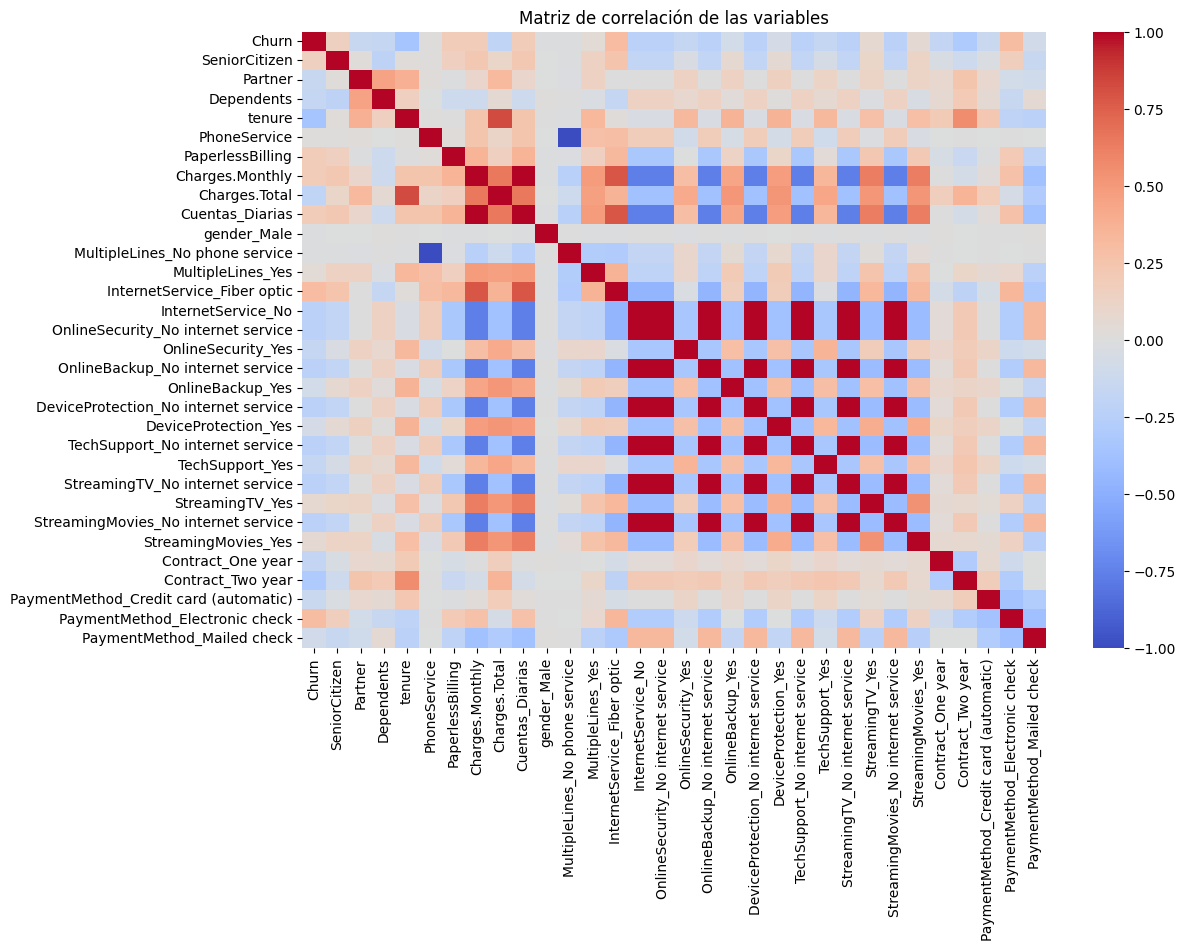

In [29]:
# Análisis de Correlación

!pip install seaborn

import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm")

plt.title("Matriz de correlación de las variables")
plt.show()

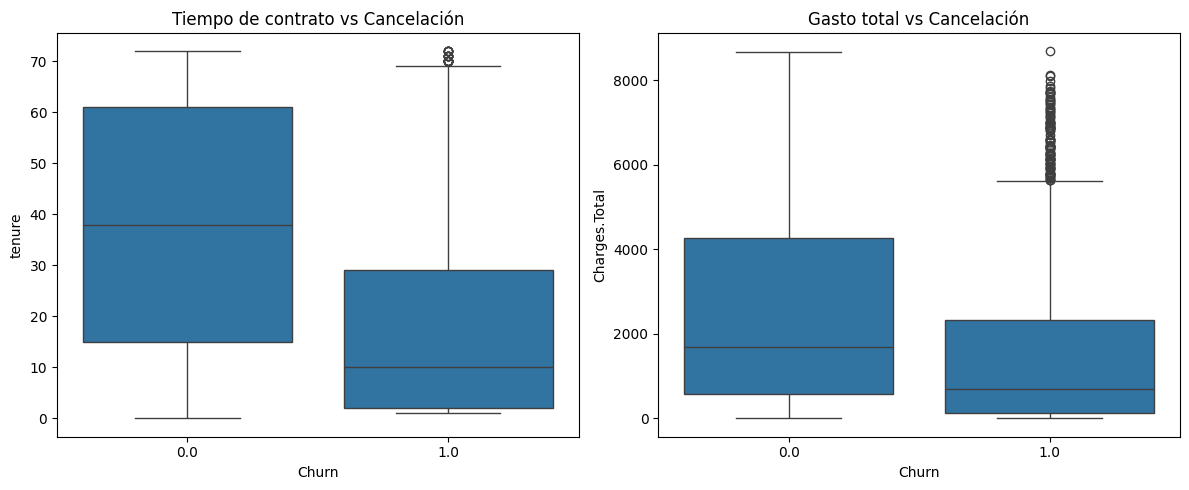

In [30]:
# Análisis Dirigido

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df["Churn"], y=df["tenure"])
plt.title("Tiempo de contrato vs Cancelación")

plt.subplot(1,2,2)

# buscar columna de gasto total automáticamente
total_col = [c for c in df.columns if "Total" in c or "total" in c][0]
sns.boxplot(x=df["Churn"], y=df[total_col])
plt.title("Gasto total vs Cancelación")

plt.tight_layout()
plt.show()

Modelado Predictivo

In [31]:
# Separación de Datos

from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento: (4930, 31)
Tamaño del conjunto de prueba: (2113, 31)


In [32]:
# Creación de Modelos

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Normalización para el modelo sensible a la escala
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo 1: Regresión Logística (requiere datos normalizados)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# Modelo 2: Random Forest (no requiere normalización)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("Modelos entrenados correctamente")

Modelos entrenados correctamente


In [33]:
# Evaluación de los Modelos

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Predicciones
y_pred_log = log_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)

def evaluar_modelo(nombre, y_test, y_pred):
    print(f"\nModelo: {nombre}")
    print("Exactitud:", accuracy_score(y_test, y_pred))
    print("Precisión:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))

evaluar_modelo("Regresión Logística", y_test, y_pred_log)
evaluar_modelo("Random Forest", y_test, y_pred_rf)


Modelo: Regresión Logística
Exactitud: 0.7983909133932797
Precisión: 0.6415094339622641
Recall: 0.5454545454545454
F1-score: 0.5895953757225434
Matriz de confusión:
[[1381  171]
 [ 255  306]]

Modelo: Random Forest
Exactitud: 0.7851396119261713
Precisión: 0.6213151927437641
Recall: 0.48841354723707664
F1-score: 0.5469061876247505
Matriz de confusión:
[[1385  167]
 [ 287  274]]


Interpretación y Conclusiones

In [34]:
# Análisis de la Importancia de las Variables

import pandas as pd

# Importancia de variables en Regresión Logística (coeficientes)
coef_log = pd.Series(log_model.coef_[0], index=X_train.columns)
coef_log = coef_log.sort_values(key=abs, ascending=False)

print("Variables más influyentes en Regresión Logística:")
print(coef_log.head(10))

# Importancia de variables en Random Forest
import_rf = pd.Series(rf_model.feature_importances_, index=X_train.columns)
import_rf = import_rf.sort_values(ascending=False)

print("\nVariables más importantes en Random Forest:")
print(import_rf.head(10))

Variables más influyentes en Regresión Logística:
tenure                        -1.457422
Charges.Total                  0.706182
InternetService_Fiber optic    0.615297
Contract_Two year             -0.564389
Cuentas_Diarias               -0.313681
Charges.Monthly               -0.313681
Contract_One year             -0.302788
PaperlessBilling               0.202033
StreamingTV_Yes                0.193647
MultipleLines_Yes              0.175889
dtype: float64

Variables más importantes en Random Forest:
Charges.Total                     0.167191
tenure                            0.156440
Charges.Monthly                   0.131701
Cuentas_Diarias                   0.128747
PaymentMethod_Electronic check    0.036285
Contract_Two year                 0.032103
InternetService_Fiber optic       0.031377
gender_Male                       0.025499
PaperlessBilling                  0.024037
Contract_One year                 0.023734
dtype: float64


Informe Final: Análisis de Cancelación de Clientes
Objetivo del análisis

El objetivo de este análisis fue identificar los factores que influyen en la cancelación de clientes (Churn) en la empresa Telecom X. Para ello, se realizó un proceso de preparación de datos, análisis exploratorio y la construcción de modelos predictivos que permitan entender qué variables están más relacionadas con la cancelación del servicio.

Preparación de los datos

Primero se cargaron los datos tratados previamente en la etapa anterior del proyecto. Luego se eliminaron columnas que no aportaban valor al análisis, como identificadores únicos. Posteriormente se transformaron las variables categóricas a formato numérico mediante one-hot encoding, lo que permitió que los modelos de machine learning pudieran utilizarlas correctamente.

También se revisó el balance de la variable objetivo Churn, y se aplicó la técnica SMOTE para balancear las clases, evitando que el modelo se sesgue hacia la clase mayoritaria.

Modelos utilizados

Se entrenaron dos modelos para predecir la cancelación de clientes:

Regresión Logística, que requiere normalización de los datos.

Random Forest, un modelo basado en árboles que no depende de la escala de las variables.

Ambos modelos fueron evaluados utilizando métricas como exactitud, precisión, recall, F1-score y matriz de confusión, lo que permitió comparar su rendimiento.

Factores que influyen en la cancelación

A partir del análisis de los coeficientes de la Regresión Logística y de la importancia de variables en Random Forest, se identificaron algunas variables que tienen mayor impacto en la cancelación de clientes.

Entre los factores más relevantes se encuentran:

Tiempo de contrato (tenure): los clientes con menor tiempo en el servicio tienden a cancelar con mayor frecuencia.

Gasto total: niveles de gasto pueden influir en la permanencia o cancelación del servicio.

Tipo de contrato y servicios contratados: algunos tipos de contratos o combinaciones de servicios pueden estar más asociados con la cancelación.

Estos factores muestran que tanto el tiempo de permanencia como la forma en que el cliente utiliza el servicio influyen en su decisión de continuar o cancelar.

Recomendaciones

A partir de los resultados obtenidos, se pueden proponer algunas estrategias para reducir la cancelación de clientes:

Programas de fidelización para clientes nuevos, especialmente durante los primeros meses de servicio.

Ofertas o beneficios para clientes con contratos cortos, incentivando contratos más largos.

Mejor análisis del comportamiento de consumo, para identificar clientes con mayor riesgo de cancelación.

Campañas de retención personalizadas, enfocadas en los clientes que presentan características similares a los que ya cancelaron.

Conclusión

El análisis permitió identificar variables importantes relacionadas con la cancelación de clientes y demostrar cómo los modelos de machine learning pueden ayudar a predecir este comportamiento. Estos resultados pueden servir como base para desarrollar estrategias que mejoren la retención de clientes y optimicen la toma de decisiones dentro de la empresa.